# 06 - Evaluation Comparative des Modeles

**Objectif**: Comparer DNN vs XGBoost sur toutes les metriques de performance.

**Metriques evaluees**:
- Accuracy, Precision, Recall, F1-score
- AUC-ROC
- Matrice de confusion
- Temps d'entrainement et d'inference

In [242]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

OUTPUT_DIR = '/kaggle/working'

print('Imports OK')

Imports OK


In [243]:
def load_json(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f'Missing file: {path}')
    with open(path, 'r') as f:
        return json.load(f)

dnn_metrics = load_json(os.path.join(OUTPUT_DIR, 'dnn_metrics.json'))
xgb_metrics = load_json(os.path.join(OUTPUT_DIR, 'xgboost_metrics.json'))
spark_metrics = load_json(os.path.join(OUTPUT_DIR, 'spark_gbt_metrics.json'))
spark_benchmark = load_json(os.path.join(OUTPUT_DIR, 'spark_benchmark.json'))

print('Metrics loaded for: DNN, XGBoost, Spark GBT')

for name, m in [("DNN", dnn_metrics), ("XGBoost", xgb_metrics), ("Spark GBT", spark_metrics)]:
    print(f'\n{name}:')
    metrics = m.get('metrics', {})
    for k, v in metrics.items():
        if isinstance(v, (int, float)):
            print(f'  {k:15s} : {v:.4f}')
        else:
            print(f'  {k:15s} : {v}')

Metrics loaded for: DNN, XGBoost, Spark GBT

DNN:
  accuracy        : 0.8225
  precision       : 0.3049
  recall          : 0.5629
  f1_score        : 0.3956
  auc_roc         : 0.8191

XGBoost:
  accuracy        : 0.7013
  precision       : 0.2287
  recall          : 0.7991
  f1_score        : 0.3557
  auc_roc         : 0.8195

Spark GBT:
  accuracy        : 0.8984
  f1_score        : 0.8604
  auc_roc         : 0.8186


## 1. Tableau Comparatif

In [244]:
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC',
               'Training time (s)', 'Inference time (s)'],
    'DNN': [
        dnn_metrics['metrics'].get('accuracy'),
        dnn_metrics['metrics'].get('precision'),
        dnn_metrics['metrics'].get('recall'),
        dnn_metrics['metrics'].get('f1_score'),
        dnn_metrics['metrics'].get('auc_roc'),
        dnn_metrics.get('training_time_seconds'),
        dnn_metrics.get('inference_time_seconds')
    ],
    'XGBoost': [
        xgb_metrics['metrics'].get('accuracy'),
        xgb_metrics['metrics'].get('precision'),
        xgb_metrics['metrics'].get('recall'),
        xgb_metrics['metrics'].get('f1_score'),
        xgb_metrics['metrics'].get('auc_roc'),
        xgb_metrics.get('training_time_seconds'),
        xgb_metrics.get('inference_time_seconds')
    ],
    'Spark GBT': [
        spark_metrics['metrics'].get('accuracy'),
        np.nan,
        np.nan,
        spark_metrics['metrics'].get('f1_score'),
        spark_metrics['metrics'].get('auc_roc'),
        spark_metrics.get('training_time_seconds'),
        spark_metrics.get('inference_time_seconds')
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print('=' * 80)
print('COMPARISON TABLE - DNN vs XGBoost vs Spark GBT')
print('=' * 80)
print(comparison_df.to_string(index=False))

comparison_df.to_csv(os.path.join(OUTPUT_DIR, 'metrics_comparison.csv'), index=False)
print('Saved metrics_comparison.csv')

COMPARISON TABLE - DNN vs XGBoost vs Spark GBT
            Metric        DNN   XGBoost  Spark GBT
          Accuracy   0.822548  0.701307   0.898417
         Precision   0.304946  0.228739        NaN
            Recall   0.562906  0.799112        NaN
          F1-Score   0.395588  0.355670   0.860422
           AUC-ROC   0.819095  0.819533   0.818598
 Training time (s) 177.770000 67.110000 270.160000
Inference time (s)   0.926600  1.508800   0.050900
Saved metrics_comparison.csv


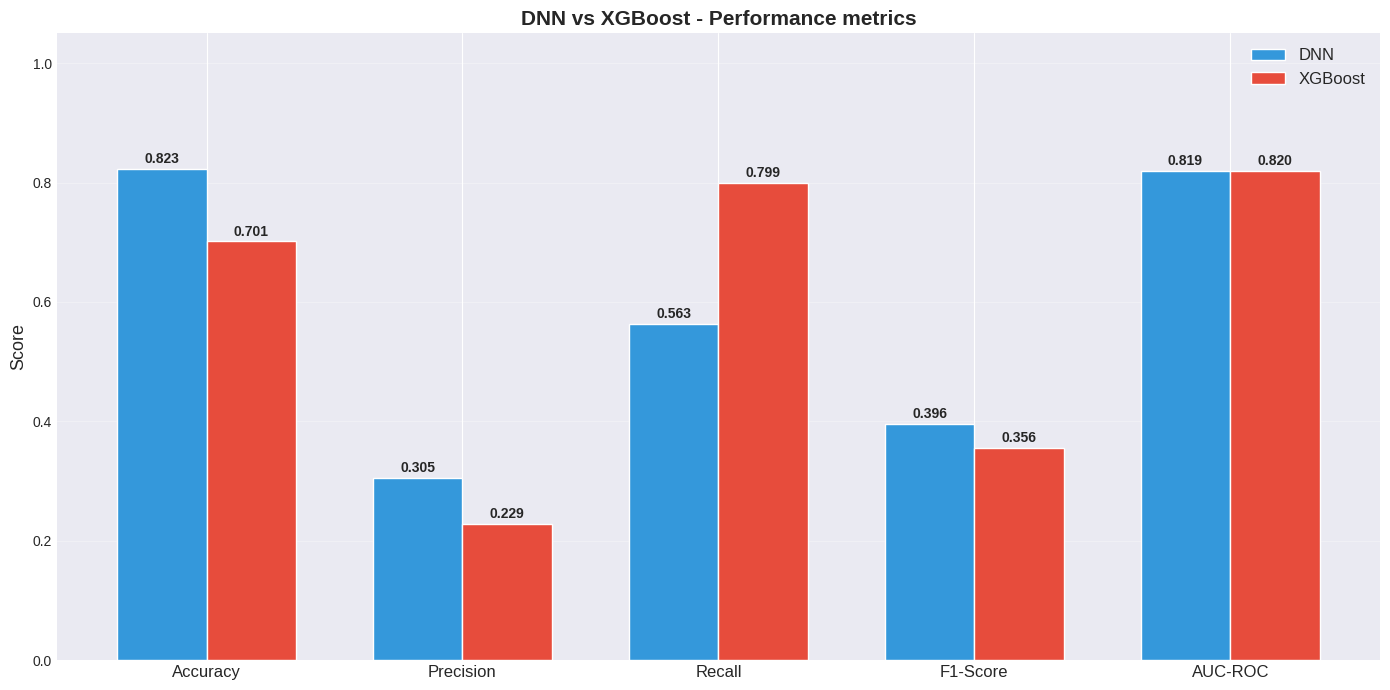

In [245]:
metrics_keys = ['accuracy', 'precision', 'recall', 'f1_score', 'auc_roc']
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

dnn_vals = [dnn_metrics['metrics'].get(k, np.nan) for k in metrics_keys]
xgb_vals = [xgb_metrics['metrics'].get(k, np.nan) for k in metrics_keys]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width / 2, dnn_vals, width, label='DNN', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width / 2, xgb_vals, width, label='XGBoost', color='#e74c3c', edgecolor='white')

for bar in bars1:
    if not np.isnan(bar.get_height()):
        ax.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    if not np.isnan(bar.get_height()):
        ax.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Score', fontsize=13)
ax.set_title('DNN vs XGBoost - Performance metrics', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'metrics_comparison_barchart.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Courbes ROC superposees

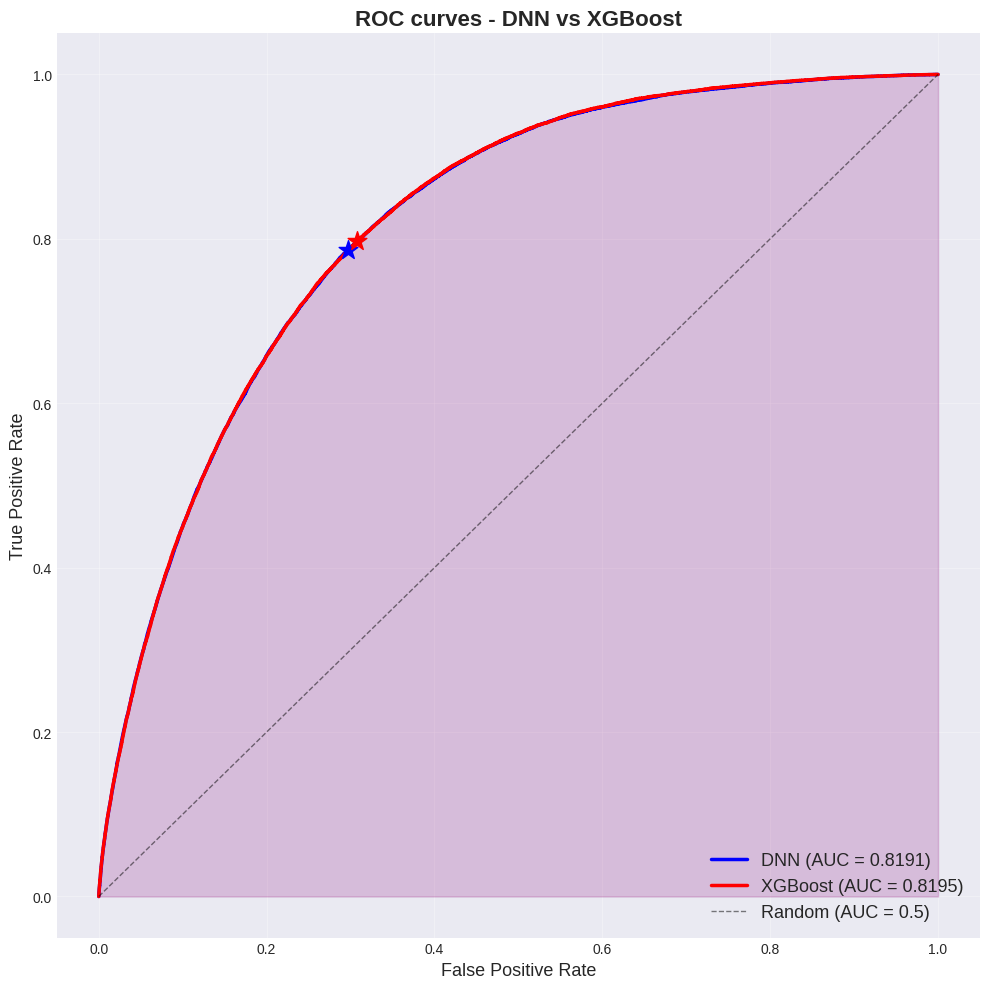

Saved roc_curves.png


In [246]:
plt.figure(figsize=(10, 10))

fpr_dnn = dnn_metrics['roc_curve']['fpr']
tpr_dnn = dnn_metrics['roc_curve']['tpr']
auc_dnn = dnn_metrics['metrics']['auc_roc']

fpr_xgb = xgb_metrics['roc_curve']['fpr']
tpr_xgb = xgb_metrics['roc_curve']['tpr']
auc_xgb = xgb_metrics['metrics']['auc_roc']

plt.plot(fpr_dnn, tpr_dnn, 'b-', linewidth=2.5, label=f'DNN (AUC = {auc_dnn:.4f})')
plt.plot(fpr_xgb, tpr_xgb, 'r-', linewidth=2.5, label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')

plt.fill_between(fpr_dnn, tpr_dnn, alpha=0.1, color='blue')
plt.fill_between(fpr_xgb, tpr_xgb, alpha=0.1, color='red')

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC curves - DNN vs XGBoost', fontsize=16, fontweight='bold')
plt.legend(fontsize=13, loc='lower right')
plt.grid(True, alpha=0.3)

j_dnn = np.array(tpr_dnn) - np.array(fpr_dnn)
optimal_idx_dnn = int(np.argmax(j_dnn))
plt.scatter(fpr_dnn[optimal_idx_dnn], tpr_dnn[optimal_idx_dnn],
            marker='*', s=200, color='blue', zorder=5)

j_xgb = np.array(tpr_xgb) - np.array(fpr_xgb)
optimal_idx_xgb = int(np.argmax(j_xgb))
plt.scatter(fpr_xgb[optimal_idx_xgb], tpr_xgb[optimal_idx_xgb],
            marker='*', s=200, color='red', zorder=5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved roc_curves.png')

## 3. Matrices de confusion cote a cote

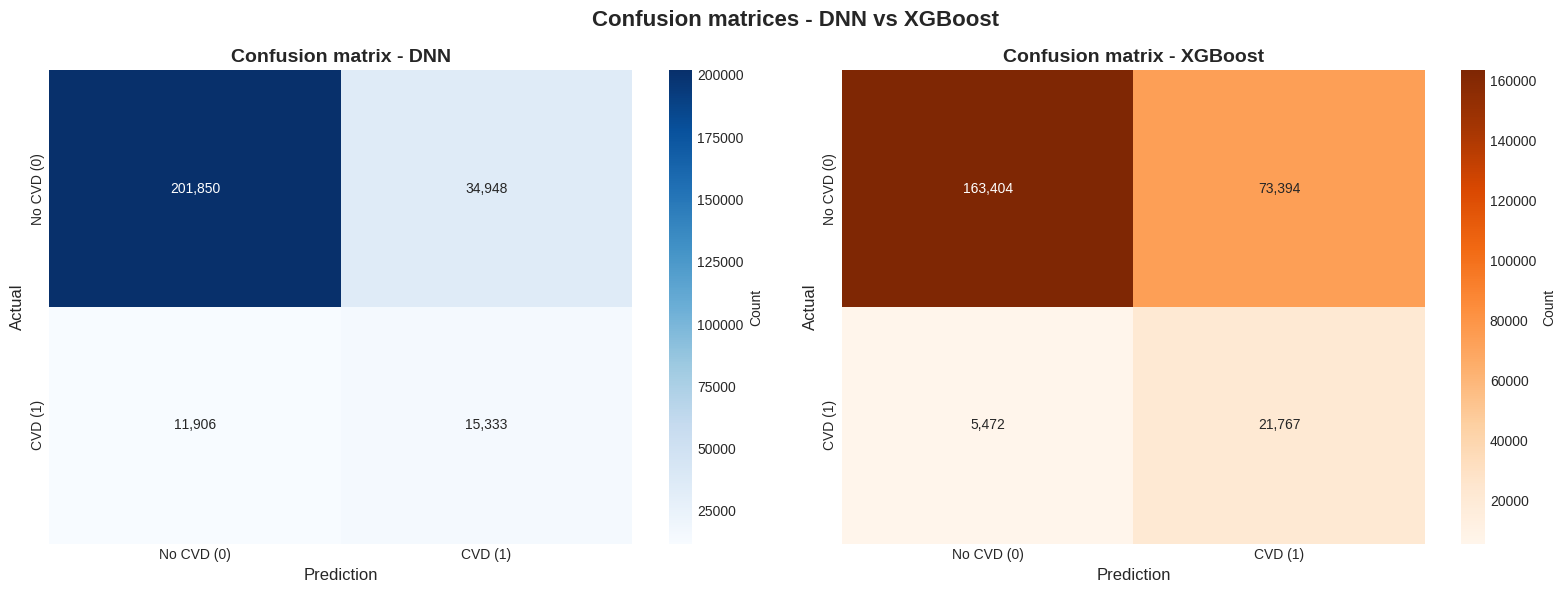

Saved confusion_matrices.png


In [247]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_dnn = np.array(dnn_metrics['confusion_matrix'])
sns.heatmap(cm_dnn, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['No CVD (0)', 'CVD (1)'],
            yticklabels=['No CVD (0)', 'CVD (1)'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Prediction', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion matrix - DNN', fontsize=14, fontweight='bold')

cm_xgb = np.array(xgb_metrics['confusion_matrix'])
sns.heatmap(cm_xgb, annot=True, fmt=',d', cmap='Oranges',
            xticklabels=['No CVD (0)', 'CVD (1)'],
            yticklabels=['No CVD (0)', 'CVD (1)'],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_xlabel('Prediction', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion matrix - XGBoost', fontsize=14, fontweight='bold')

plt.suptitle('Confusion matrices - DNN vs XGBoost', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrices.png')

## 4. Radar chart - Vue d'ensemble

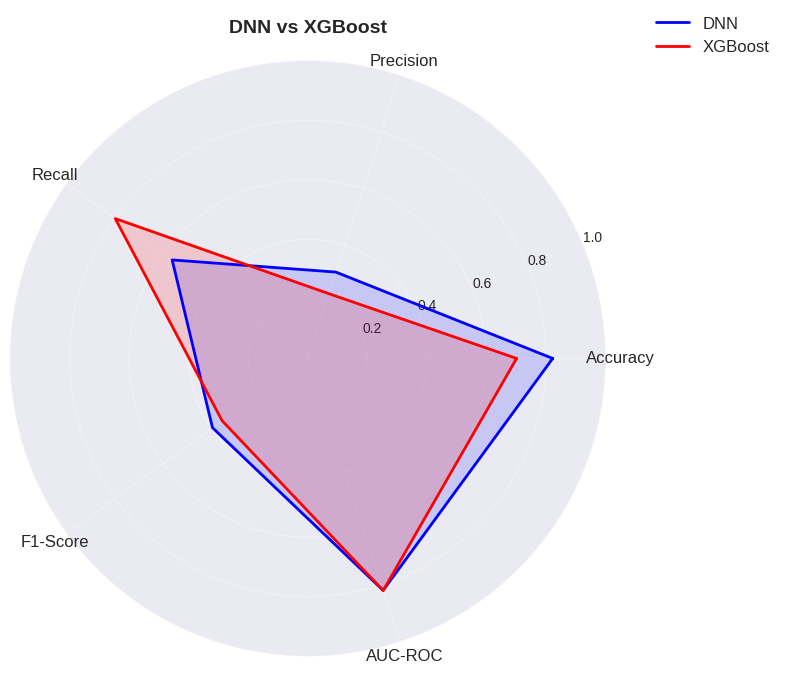

In [248]:
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

dnn_values = [
    dnn_metrics['metrics']['accuracy'],
    dnn_metrics['metrics']['precision'],
    dnn_metrics['metrics']['recall'],
    dnn_metrics['metrics']['f1_score'],
    dnn_metrics['metrics']['auc_roc']
]

xgb_values = [
    xgb_metrics['metrics']['accuracy'],
    xgb_metrics['metrics']['precision'],
    xgb_metrics['metrics']['recall'],
    xgb_metrics['metrics']['f1_score'],
    xgb_metrics['metrics']['auc_roc']
]

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
dnn_values_plot = dnn_values + [dnn_values[0]]
xgb_values_plot = xgb_values + [xgb_values[0]]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, dnn_values_plot, 'b-', linewidth=2, label='DNN')
ax.fill(angles, dnn_values_plot, 'blue', alpha=0.15)
ax.plot(angles, xgb_values_plot, 'r-', linewidth=2, label='XGBoost')
ax.fill(angles, xgb_values_plot, 'red', alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('DNN vs XGBoost', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'metrics_radar_chart.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Comparaison des temps d'execution

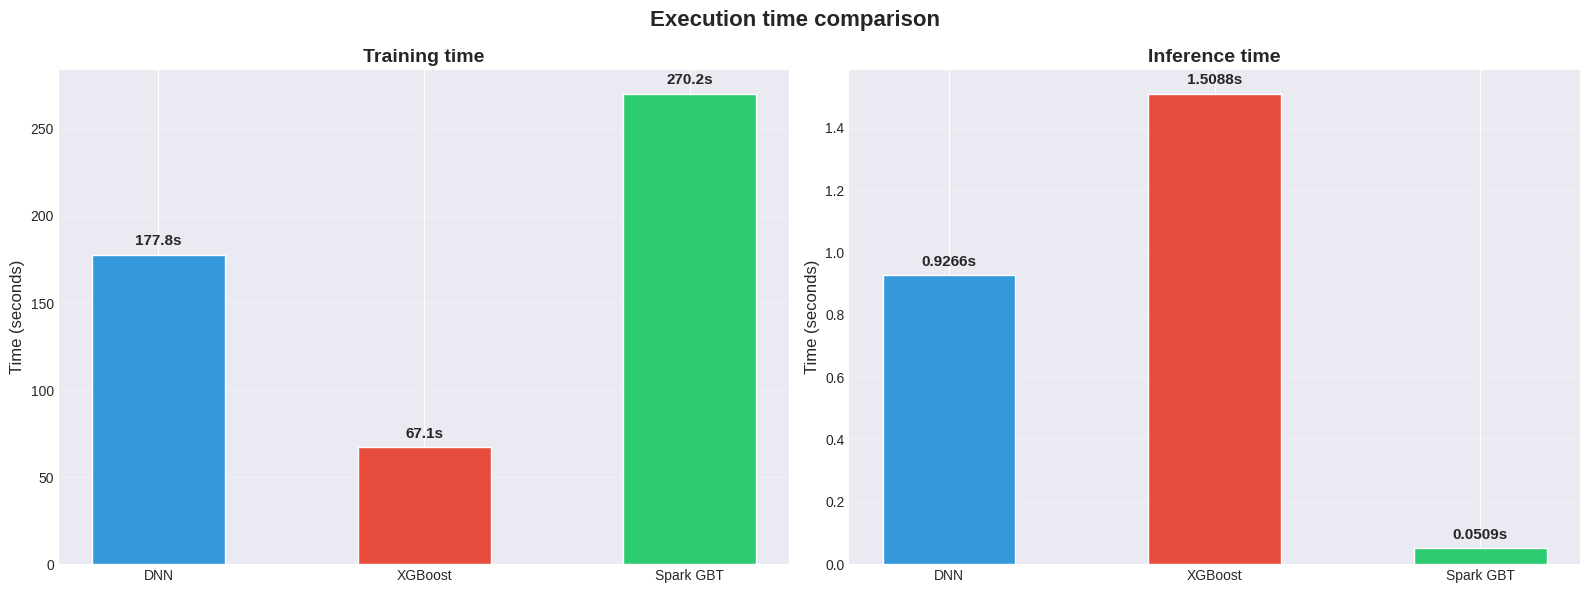

In [249]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = ['DNN', 'XGBoost', 'Spark GBT']
train_times = [
    dnn_metrics['training_time_seconds'],
    xgb_metrics['training_time_seconds'],
    spark_metrics['training_time_seconds']
]
colors = ['#3498db', '#e74c3c', '#2ecc71']

axes[0].bar(models, train_times, color=colors, edgecolor='white', width=0.5)
for i, t in enumerate(train_times):
    axes[0].text(i, t + max(train_times) * 0.02, f'{t:.1f}s',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Time (seconds)', fontsize=12)
axes[0].set_title('Training time', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

inference_times = [
    dnn_metrics['inference_time_seconds'],
    xgb_metrics['inference_time_seconds'],
    spark_metrics['inference_time_seconds']
]

axes[1].bar(models, inference_times, color=colors, edgecolor='white', width=0.5)
for i, t in enumerate(inference_times):
    axes[1].text(i, t + max(inference_times) * 0.02, f'{t:.4f}s',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Time (seconds)', fontsize=12)
axes[1].set_title('Inference time', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Execution time comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'timing_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Analyse de l'impact Spark

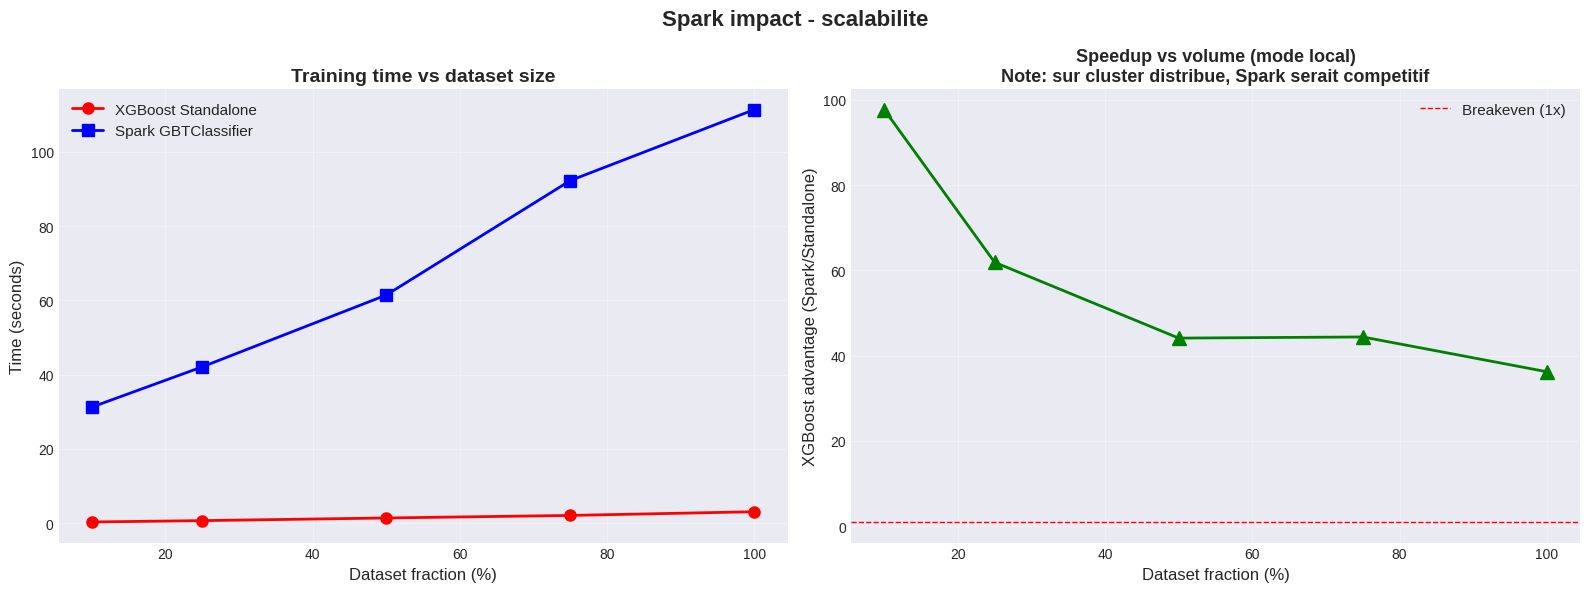

Note: En mode local, Spark est ~36-97x plus lent que XGBoost standalone.
Sur un cluster distribue (8+ noeuds), Spark deviendrait competitif sur > 10M lignes.


In [250]:
bench_results = spark_benchmark.get('results', [])
if not bench_results:
    print('WARNING: spark_benchmark has no results — skipping Spark scalability plot')
else:
    fractions = [r['fraction'] * 100 for r in bench_results]
    spark_t = [r['spark_time'] for r in bench_results]
    standalone_t = [r['standalone_time'] for r in bench_results]
    xgb_advantage = [
        (s / x) if x > 0 else 0 for s, x in zip(spark_t, standalone_t)
    ]   # correction : crochet fermant manquant dans la version originale

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].plot(fractions, standalone_t, 'ro-', linewidth=2, markersize=8, label='XGBoost Standalone')
    axes[0].plot(fractions, spark_t, 'bs-', linewidth=2, markersize=8, label='Spark GBTClassifier')
    axes[0].set_xlabel('Dataset fraction (%)', fontsize=12)
    axes[0].set_ylabel('Time (seconds)', fontsize=12)
    axes[0].set_title('Training time vs dataset size', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(fractions, xgb_advantage, 'g^-', linewidth=2, markersize=10)
    axes[1].axhline(y=1, color='red', linestyle='--', linewidth=1, label='Breakeven (1x)')
    axes[1].set_xlabel('Dataset fraction (%)', fontsize=12)
    axes[1].set_ylabel('XGBoost advantage (Spark/Standalone)', fontsize=12)
    axes[1].set_title('Speedup vs volume (mode local)\nNote: sur cluster distribue, Spark serait competitif',
                      fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Spark impact - scalabilite', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'spark_scalability.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print('Note: En mode local, Spark est ~36-97x plus lent que XGBoost standalone.')
    print('Sur un cluster distribue (8+ noeuds), Spark deviendrait competitif sur > 10M lignes.')

## 7. Analyse du desequilibre de classes

CLASS IMBALANCE ANALYSIS
Positive class rate: ~9.4% (reference)
DNN recall (class 1): 0.5629
XGBoost recall (class 1): 0.7991


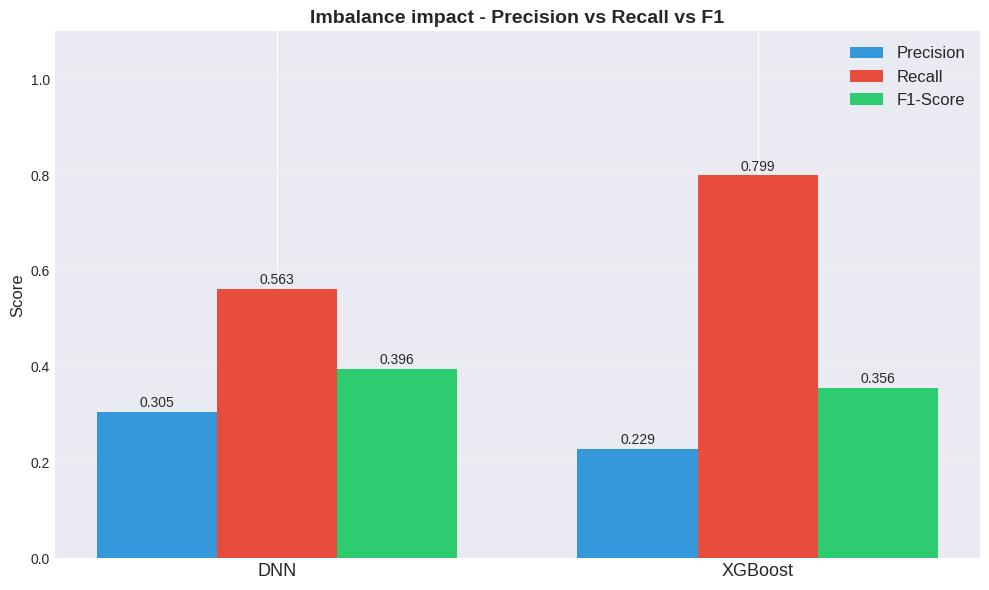

In [251]:
print('=' * 70)
print('CLASS IMBALANCE ANALYSIS')
print('=' * 70)

print('Positive class rate: ~9.4% (reference)')
print(f"DNN recall (class 1): {dnn_metrics['metrics']['recall']:.4f}")
print(f"XGBoost recall (class 1): {xgb_metrics['metrics']['recall']:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))

models_name = ['DNN', 'XGBoost']
precisions = [dnn_metrics['metrics']['precision'], xgb_metrics['metrics']['precision']]
recalls = [dnn_metrics['metrics']['recall'], xgb_metrics['metrics']['recall']]
f1s = [dnn_metrics['metrics']['f1_score'], xgb_metrics['metrics']['f1_score']]

x_pos = np.arange(len(models_name))
width = 0.25

ax.bar(x_pos - width, precisions, width, label='Precision', color='#3498db')
ax.bar(x_pos, recalls, width, label='Recall', color='#e74c3c')
ax.bar(x_pos + width, f1s, width, label='F1-Score', color='#2ecc71')

for i in range(len(models_name)):
    ax.text(i - width, precisions[i] + 0.01, f'{precisions[i]:.3f}', ha='center', fontsize=10)
    ax.text(i, recalls[i] + 0.01, f'{recalls[i]:.3f}', ha='center', fontsize=10)
    ax.text(i + width, f1s[i] + 0.01, f'{f1s[i]:.3f}', ha='center', fontsize=10)

ax.set_xticks(x_pos)
ax.set_xticklabels(models_name, fontsize=13)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Imbalance impact - Precision vs Recall vs F1', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_imbalance_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Conclusions et recommandations

In [ ]:
print('=' * 70)
print('FINAL SUMMARY - MODEL COMPARISON')
print('=' * 70)

# Use optimal threshold metrics when available for fair DNN vs XGBoost comparison
dnn_m_cmp = dnn_metrics.get('metrics_optimal_threshold', dnn_metrics.get('metrics', {}))
xgb_m_cmp = xgb_metrics.get('metrics_optimal_threshold', xgb_metrics.get('metrics', {}))
dnn_thresh = dnn_metrics.get('optimal_threshold', 0.5)
xgb_thresh = xgb_metrics.get('optimal_threshold', 0.5)

print(f"DNN threshold: {dnn_thresh:.4f} | XGBoost threshold: {xgb_thresh:.4f}")

metrics_names = ['accuracy', 'precision', 'recall', 'f1_score', 'auc_roc']
for m in metrics_names:
    dnn_val = dnn_m_cmp.get(m)
    xgb_val = xgb_m_cmp.get(m)
    if dnn_val is not None and xgb_val is not None:
        winner = 'DNN' if dnn_val > xgb_val else 'XGBoost'
        diff = abs(dnn_val - xgb_val)
        print(f'  {m:15s} - DNN: {dnn_val:.4f} | XGBoost: {xgb_val:.4f} | Winner: {winner} (+{diff:.4f})')

print('\n' + '=' * 70)
print('PRD CRITERIA CHECK')
print('=' * 70)

dnn_auc = dnn_metrics.get('metrics', {}).get('auc_roc', 0.0)
xgb_auc = xgb_metrics.get('metrics', {}).get('auc_roc', 0.0)
max_f1 = max(dnn_m_cmp.get('f1_score', 0.0), xgb_m_cmp.get('f1_score', 0.0))
max_recall = max(
    dnn_metrics.get('metrics_threshold_05', dnn_metrics.get('metrics', {})).get('recall', 0.0),
    xgb_metrics.get('metrics_threshold_05', xgb_metrics.get('metrics', {})).get('recall', 0.0)
)

criteria = [
    ('AUC-ROC DNN >= 0.85', dnn_auc >= 0.85, dnn_auc),
    ('AUC-ROC XGBoost >= 0.87', xgb_auc >= 0.87, xgb_auc),
    ('F1-score positive >= 0.60', max_f1 >= 0.60, max_f1),
    ('Recall positive >= 0.65', max_recall >= 0.65, max_recall)
]

for criterion, passed, value in criteria:
    status = 'PASS' if passed else 'FAIL'
    print(f'  {status} - {criterion} (value: {value:.4f})')

# FIXED (CRIT-1): sanitize NaN → None before json.dump to produce valid RFC 8259 JSON
import math

def _clean_nan(obj):
    if isinstance(obj, float) and math.isnan(obj):
        return None
    if isinstance(obj, dict):
        return {k: _clean_nan(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_clean_nan(v) for v in obj]
    return obj

final_summary = {
    'comparison': comparison_df.to_dict('records'),
    'best_model_by_metric': {
        m: 'DNN' if (dnn_m_cmp.get(m) or 0) > (xgb_m_cmp.get(m) or 0) else 'XGBoost'
        for m in metrics_names
        if m in dnn_m_cmp and m in xgb_m_cmp
    },
    'criteria_check': {c: p for c, p, _ in criteria},
    'dnn_metrics': dnn_m_cmp,
    'dnn_metrics_threshold_05': dnn_metrics.get('metrics_threshold_05', {}),
    'xgboost_metrics': xgb_m_cmp,
    'xgboost_metrics_threshold_05': xgb_metrics.get('metrics_threshold_05', xgb_metrics.get('metrics', {})),
    'spark_gbt_metrics': spark_metrics.get('metrics', {}),
    'timing': {
        'dnn_training': dnn_metrics.get('training_time_seconds'),
        'xgboost_training': xgb_metrics.get('training_time_seconds'),
        'spark_training': spark_metrics.get('training_time_seconds')
    }
}

with open(os.path.join(OUTPUT_DIR, 'final_results_summary.json'), 'w') as f:
    json.dump(_clean_nan(final_summary), f, indent=2)
print('Saved final_results_summary.json')

## Resume du notebook 06

- Tableau comparatif complet DNN vs XGBoost vs Spark GBT
- Courbes ROC superposees
- Matrices de confusion cote a cote
- Radar chart
- Analyse timing (entrainement + inference)
- Analyse de scalabilite Spark
- Analyse de l'impact du desequilibre de classes
- Verification des criteres PRD
- Tous les artifacts exportes

Next: move to Phase 6 for the Streamlit dashboard